In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np

loc = Path.cwd()

print(loc)
json_file=[]

/home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare


In [2]:
imgNetF = loc / "resNet_data"

# Find and read all JSON files recursively
for file_path in imgNetF.rglob("*.json"):
    print(f"Found: {file_path}")
    json_file.append(file_path)
        



Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare/resNet_data/inat_resnet18_500_ptclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare/resNet_data/inat_resnet50_500_ptclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare/resNet_data/inat_resnet18_500_npclasses_imagenet_history.json
Found: /home/sergiocloudwork/COMP9517GROUP_SUBJECT/src/performenceCompare/resNet_data/inat_resnet50_500_npclasses_imagenet_history.json


In [3]:
import json

json_data=[]
# Find and read all JSON files recursively
for file_path in json_file:    
    print(file_path.name)
    try:
        # read_text() reads content; json.loads() parses it
        data = json.loads(file_path.read_text(encoding="utf-8"))
        print(data)
        json_data.append(data)
        # Process your data here
    except json.JSONDecodeError:
        print(f"Error: {file_path.name} is not a valid JSON file.")

model_name={"inat_resnet18_500_ptclasses_imagenet_history.json":"ResNet18 pretrained model",
            "inat_resnet50_500_ptclasses_imagenet_history.json":"ResNet50 pretrained model",
            "inat_resnet18_500_npclasses_imagenet_history.json":"ResNet18 random start model",
            "inat_resnet50_500_npclasses_imagenet_history.json":"ResNet50 random start model"
            }

assert len(model_name.keys())==len(json_file)

inat_resnet18_500_ptclasses_imagenet_history.json
{'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], 'train_loss': [5.92791964263916, 5.099748748016357, 4.5671359676361085, 4.159114964294433, 3.8180081958770753, 3.5519068359375, 3.414197621536255, 3.279997703552246, 3.149191273498535, 3.0366964141845703, 2.9270978160858157, 2.869529429244995, 2.8190180866241454, 2.7665734870910645, 2.7153107734680177, 2.6653442031860353, 2.6433347019195557, 2.6192675613403322, 2.588008197784424, 2.5669028671264646, 2.55097763671875, 2.5343689434051515, 2.5279040882110597, 2.5136897415161132, 2.49913938999176, 2.493152185821533, 2.4888148975372313, 2.481156540679932, 2.4728222246170044, 2.4706772764205933, 2.462552716255188, 2.4613326765060424, 2.457811148071289, 2.454640846633911, 2.4526666223526, 2.4495118330001833, 2.447210202598572, 2.444815578079224, 2.448024742126465, 2.4416953796386

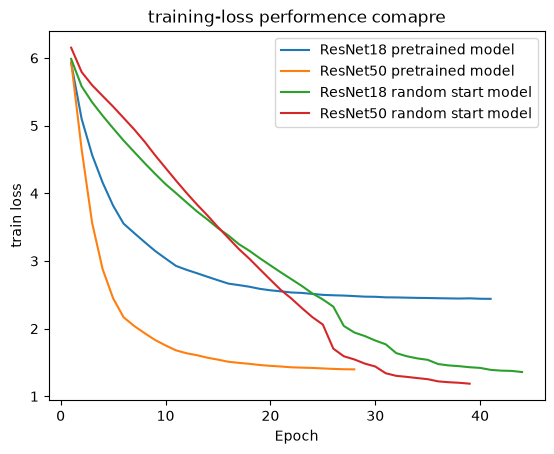

In [4]:
# train loss

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train loss")
plt.title("training-loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

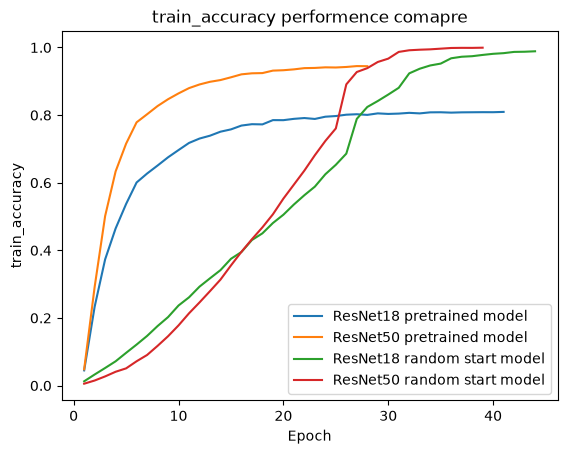

In [5]:
# train acc

for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['train_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("train_accuracy")
plt.title("train_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

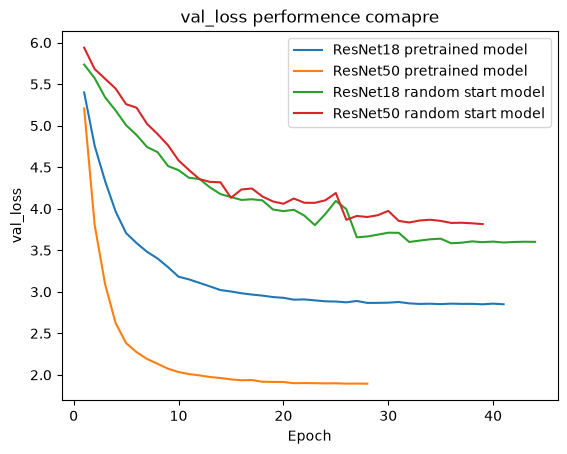

In [6]:
# val loss


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_loss'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_loss")
plt.title("val_loss performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

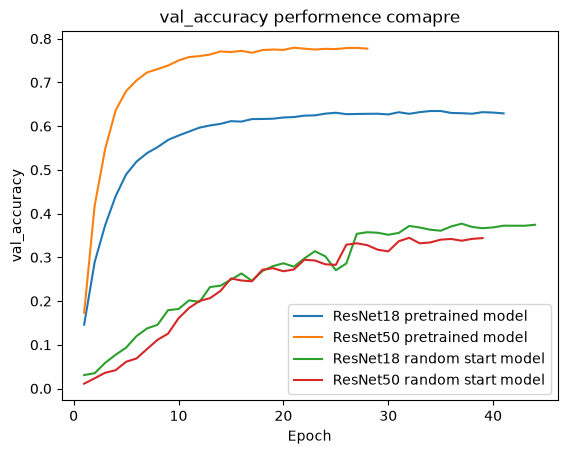

In [7]:
# train acc


for dt in range(len(json_data)):
    plt.plot(json_data[dt]['epoch'], json_data[dt]['val_accuracy'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("val_accuracy")
plt.title("val_accuracy performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib

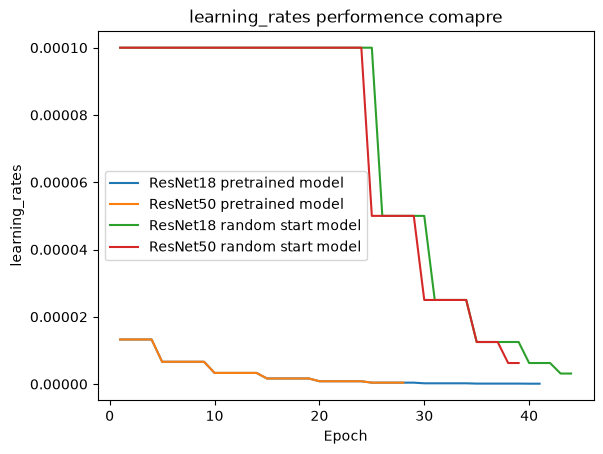

In [8]:
# learning rate

for dt in range(len(json_data)):
    if type(json_data[dt]['learning_rates'][0]) == list:
        row_averages = [sum(row) / len(row) for row in json_data[dt]['learning_rates']]
        plt.plot(json_data[dt]['epoch'], row_averages, label=model_name[json_file[dt].name], linestyle="-")

    else:
        plt.plot(json_data[dt]['epoch'], json_data[dt]['learning_rates'], label=model_name[json_file[dt].name], linestyle="-")

    
# # Add a legend, labels, and show the plot
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("learning_rates")
plt.title("learning_rates performence comapre")
plt.show()



# https://stackoverflow.com/questions/16006572/plotting-different-colors-in-matplotlib